In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from copy import deepcopy
from EventDriven.backtest import OptionSignalBacktest, OptionSignalPortfolio
from EventDriven.riskmanager.new_base import RiskManager
from EventDriven.riskmanager.utils import get_use_temp_cache, set_use_temp_cache
import json
from EventDriven.types import OrderData, OrderDataDict
from trade import set_pool_enabled
from EventDriven.configs.core import DefaultSizerConfigs, ZscoreSizerConfigs, BacktesterConfig, LimitsEnabledConfig
from EventDriven.riskmanager.position.cogs.limits import LimitsAndSizingCog
from EventDriven.configs.export_configs import collect_run_configs, walk_configs, tag_run, export_run_configs, RunConfigBundle
set_pool_enabled(False)  # Disable multiprocessing for debugging
from EventDriven.dataclasses.states import PositionState, PortfolioState
from EventDriven.configs.base import BaseConfigs

order_data = OrderData.from_dict(
    {
        "trade_id": "&L:BA20240920C230&S:BA20240920C235",
        "long": ["BA20240920C230"],
        "short": ["BA20240920C235"],
        "close": np.float64(3.0250000000000057),
        "quantity": 66,
    }
)

sample_positions = {'BA': {'BA20240103LONG': {'position': order_data,
   'quantity': 65,
   'entry_price': np.float64(19728.795024479812),
   'market_value': np.float64(19662.500000000036),
   'signal_id': 'BA20240103LONG'}}}



Console Logging & File Logging Can be configured using STREAM_LOG_LEVEL and FILE_LOG_LEVEL in environment variables.
Propagate to root logger can be set using PROPAGATE_TO_ROOT_LOGGER in environment variables.
Example:
STREAM_LOG_LEVEL = 'DEBUG'
FILE_LOG_LEVEL = 'INFO'
PROPAGATE_TO_ROOT_LOGGER = 'False'

2025-12-07 20:50:50 trade.helpers.Logging INFO: Logging Root Directory: /Users/chiemelienwanisobi/cloned_repos/QuantTools/logs
Using Proxy URL: http://54.205.248.219:5500/thetadata
Using Proxy URL: http://54.205.248.219:5500/thetadata


Scheduled Data Requests will be saved to: /Users/chiemelienwanisobi/cloned_repos/QuantTools/module_test/raw_code/DataManagers/scheduler/requests.jsonl
2025-12-07 20:51:27 DataManager.py CRITICAL: Using ProcessSaveManager for saving data.


Scheduled Data Requests will be saved to: /Users/chiemelienwanisobi/cloned_repos/QuantTools/module_test/raw_code/DataManagers/scheduler/requests.jsonl
2025-12-07 20:51:27 DataManager.py CRITICAL: Using ProcessSaveMan

Loading BokehJS ...

In [ ]:
BaseConfigs.display_and_describe_all_configs()


Configuration Class: PositionAnalyzerConfig
Description: Configuration for the position analyzer orchestrating multiple cogs for comprehensive position analysis.

Configuration for the position analyzer orchestrating multiple cogs for comprehensive position analysis.


Current Configuration Settings for PositionAnalyzerConfig:
{'run_name': '', 'enabled': True, 'enabled_cogs': []}
        

Configuration Descriptions for PositionAnalyzerConfig:
- run_name:   # A name identifier for this run/session, used to tag and track configuration across backtest runs.
- enabled: True  # Flag to enable or disable the position analyzer (default True).
- enabled_cogs: []  # List of cog names that are enabled for position analysis.


Configuration Class: SkipCalcConfig
Description: Configuration for anomaly detection in option data, determining when to skip calculations due to data quality issues.

Configuration for anomaly detection in option data, determining when to skip calculations due to data qu

: 

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
_key = 10
with open(
    f"/Users/chiemelienwanisobi/cloned_repos/QuantTools/EventDriven/input/profitable_weights_{_key}.json", "r"
) as f:
    weights = json.load(f)
ttrades__ = pd.read_csv(
    f"/Users/chiemelienwanisobi/cloned_repos/QuantTools/EventDriven/input/profitable_trades_{_key}.csv"
).iloc[:, 1:]
ttrades__["Duration"] = ttrades__.Duration.apply(lambda x: int(x.split(" ")[0]))
tick = ["AAPL", "NFLX", "NVDA"]
trades_ = ttrades__#.iloc[-3:]
symbol_list = list(weights.keys())
cash = 20_000
# trades_.iloc[0, 8] = pd.NaT
# trades_ = trades_.iloc[3].to_frame().T
# trades_.iloc[0, 8] = '2025-01-05'
trades_ = trades_.iloc[:30]
trades_

,Size,EntryBar,ExitBar,EntryPrice,ExitPrice,PnL,ReturnPct,EntryTime,ExitTime,Duration,Ticker
0,105,504,551,103.049417,100.110001,-308.638768,-0.028524,2023-01-04,2023-03-14,69,SBUX
1,12,504,675,195.863123,213.759995,214.762462,0.091374,2023-01-04,2023-09-11,250,BA
2,894,514,752,17.095625,49.813000,29249.332740,1.913786,2023-01-19,2023-12-29,344,NVDA
3,14,517,687,358.781354,382.399994,330.660962,0.065830,2023-01-24,2023-09-27,246,NFLX
4,26,521,752,149.932939,358.989990,5435.483341,1.394337,2023-01-30,2023-12-29,333,META
5,139,524,683,84.585016,98.599998,1948.082575,0.165691,2023-02-02,2023-09-21,231,AMD
6,66,525,540,148.548104,147.710007,-55.314406,-0.005642,2023-02-03,2023-02-27,24,AAPL
7,63,545,708,154.328258,170.369995,1010.629422,0.103946,2023-03-06,2023-10-26,234,AAPL
8,96,575,587,109.251048,104.269997,-478.180907,-0.045593,2023-04-18,2023-05-04,16,SBUX
9,55,583,708,108.107058,120.629997,688.761639,0.115838,2023-04-28,2023-10-26,181,AMZN


In [3]:
## Setup Backtest Object
pd.options.display.max_rows = 50
pd.options.display.max_columns = 50

evb_backtest = OptionSignalBacktest(trades_, initial_capital=cash)
rm = evb_backtest.risk_manager
pm = evb_backtest.portfolio
picker = rm.order_picker
market_data = rm.market_data
analyzer = rm.position_analyzer
scheduler = evb_backtest.eventScheduler

[get_engine] Creating engine for DB: securities_master, PID: 49061


In [4]:
## Extract Configs
pd.options.display.max_rows = 50
pd.options.display.max_columns = 50

# evb_backtest = OptionSignalBacktest(trades_, initial_capital=cash)
confs = collect_run_configs(evb_backtest, debug=False)
confs

{'BacktesterConfig_1': BacktesterConfig(run_name='', t_plus_n=1, finalize_trades=False, raise_errors=False, min_slippage_pct=0.075, max_slippage_pct=0.15),
 'RiskManagerConfig_1': RiskManagerConfig(run_name='', min_slippage_pct=0.25, max_slippage_pct=0.16, cache_orders=False, cache_position_analysis=False, cache_order_requests=False),
 'ChainConfig_1': ChainConfig(run_name='', max_pct_width=None, min_oi=None),
 'OrderPickerConfig_1': OrderPickerConfig(run_name='', start_date=datetime.date(2017, 1, 1), end_date=datetime.date(2025, 12, 7)),
 'OrderSchemaConfigs_1': OrderSchemaConfigs(run_name='', target_dte=270, strategy='vertical', structure_direction='long', spread_ticks=1, dte_tolerance=60, min_moneyness=0.65, max_moneyness=1, min_total_price=0.95),
 'OrderResolutionConfig_1': OrderResolutionConfig(run_name='', resolve_enabled=True, otm_moneyness_width=0.45, itm_moneyness_width=0.45, max_close=10.0, max_tries=20, max_dte_tolerance=90),
 'SkipCalcConfig_1': SkipCalcConfig(run_name='', 

In [6]:
## Modify Configs
## Order Schema
confs["OrderSchemaConfigs_1"].target_dte = 270
confs["OrderSchemaConfigs_1"].strategy = "vertical"
confs["OrderSchemaConfigs_1"].structure_direction = "long"
confs["OrderSchemaConfigs_1"].spread_ticks = 1
confs["OrderSchemaConfigs_1"].dte_tolerance = 60
confs["OrderSchemaConfigs_1"].min_moneyness = 0.65
confs["OrderSchemaConfigs_1"].max_moneyness = 1.0
confs["OrderSchemaConfigs_1"].min_total_price = 0.95

## OrderResolution
confs["OrderResolutionConfig_1"].max_tries = 15
confs["OrderResolutionConfig_1"].otm_moneyness_width = 0.45
confs["OrderResolutionConfig_1"].itm_moneyness_width = 0.1
confs["OrderResolutionConfig_1"].max_dte_tolerance = 95

## SkipCalc
confs["SkipCalcConfig_1"].skip_enabled = True
confs["SkipCalcConfig_1"].window = 20
confs["SkipCalcConfig_1"].skip_threshold = 3.0
confs["SkipCalcConfig_1"].abs_zscore_threshold = True
confs["SkipCalcConfig_1"].pct_zscore_threshold = True
confs["SkipCalcConfig_1"].spike_flag = True
confs["SkipCalcConfig_1"].std_window_bool = True
confs["SkipCalcConfig_1"].zero_filter = True

## LimitsEnabled
confs["LimitsEnabledConfig_1"].enabled = True
confs["LimitsEnabledConfig_1"].default_dte = 120
confs["LimitsEnabledConfig_1"].default_moneyness = 1.20

## Sizer
new_sizer_conf = ZscoreSizerConfigs(
    sizing_lev=4.5,
    rvol_window=[5, 20, 63],
    rolling_window=100,
    weights=[0.5, 0.3, 0.2],
    vol_type="weighted_mean",
    norm_const=2.0
)

confs["RiskManagerConfig_1"].cache_orders=True
confs["RiskManagerConfig_1"].cache_position_analysis = True
confs["RiskManagerConfig_1"].cache_order_requests = True
confs["PositionAnalyzerConfig_1"].enabled=True
confs["ChainConfig_1"].max_pct_width=0.2
confs["ChainConfig_1"].min_oi=5

## Portfolio Configs
confs["PortfolioManagerConfig_1"].roll_failed_orders = False
evb_backtest.config.raise_errors = True
evb_backtest.config.t_plus_n = 1
evb_backtest.config.max_slippage_pct = 0.125
evb_backtest.config.min_slippage_pct = 0.05

## Additional Modifications
pm.config.weights_haircut = 0.05
pm.weight_map = weights
lmt_cog = evb_backtest.risk_manager.position_analyzer.cogs[0]
lmt_cog.sizer_configs = new_sizer_conf

## Re-tag confs
tag_run(evb_backtest, run_name="long_bbands")
confs = collect_run_configs(evb_backtest, debug=False)
exported = export_run_configs(evb_backtest,)


2025-12-07 20:47:50 EventDriven.configs.base WARNING: Attempting to set attribute 'run_name' to 'long_bbands' in ZscoreSizerConfigs...
2025-12-07 20:47:50 EventDriven.configs.base CRITICAL: Failed to validate field 'rvol_window' in ZscoreSizerConfigs. Error: Subscripted generics cannot be used with class and instance checks
2025-12-07 20:47:50 EventDriven.configs.base CRITICAL: Failed to validate field 'rvol_window' in ZscoreSizerConfigs. Error: Subscripted generics cannot be used with class and instance checks


In [7]:
exported.save_to_yaml("/Users/chiemelienwanisobi/cloned_repos/configs/prod_strategies/long_bbands/backtest_config.yaml")


In [8]:

conf_bundle = RunConfigBundle.load_from_yaml(
    "/Users/chiemelienwanisobi/cloned_repos/configs/prod_strategies/long_bbands/backtest_config.yaml"
)
conf_bundle

RunConfigBundle(run_name='long_bbands', created_at=datetime.datetime(2025, 11, 29, 16, 31, 28, 736350), configs=['BacktesterConfig', 'RiskManagerConfig', 'ChainConfig', 'OrderPickerConfig', 'OrderSchemaConfigs', 'OrderResolutionConfig', 'SkipCalcConfig', 'UndlTimeseriesConfig', 'OptionPriceConfig', 'PositionAnalyzerConfig', 'ZscoreSizerConfigs', 'LimitsEnabledConfig', 'StrategyLimitsEnabled', 'CashAllocatorConfig', 'PortfolioManagerConfig'])

In [173]:
conf_bundle.configs

{'BacktesterConfig_1': BacktesterConfig(run_name='bkt_test_11', t_plus_n=1, finalize_trades=False, raise_errors=True, min_slippage_pct=0.05, max_slippage_pct=0.125),
 'RiskManagerConfig_1': RiskManagerConfig(run_name='bkt_test_11', min_slippage_pct=0.25, max_slippage_pct=0.16, cache_orders=True, cache_position_analysis=True, cache_order_requests=True),
 'ChainConfig_1': ChainConfig(run_name='bkt_test_11', max_pct_width=0.2, min_oi=5),
 'OrderPickerConfig_1': OrderPickerConfig(run_name='bkt_test_11', start_date=datetime.date(2017, 1, 1), end_date=datetime.date(2025, 1, 31)),
 'OrderSchemaConfigs_1': OrderSchemaConfigs(run_name='bkt_test_11', target_dte=270, strategy='vertical', structure_direction='long', spread_ticks=1, dte_tolerance=60, min_moneyness=0.65, max_moneyness=1.0, min_total_price=0.95),
 'OrderResolutionConfig_1': OrderResolutionConfig(run_name='bkt_test_11', resolve_enabled=True, otm_moneyness_width=0.45, itm_moneyness_width=0.1, max_close=10.0, max_tries=15, max_dte_toler

In [141]:
import yaml
filename = "/Users/chiemelienwanisobi/cloned_repos/configs/prod_strategies/long_bbands/trade_meta.yaml"
template_conf = {
    "traded_symbols": [],
    "ruin_value": 0.0,
    "warmup_period": 300,
    "cash": 20_000,
    "weights_last_refresh": "",
    "official_start_date": "",
    "open_missed_signals": True,
    "strat_name": "LongBBandsTrend_SL",
    "strat_slug": "long_bbands",
    "executor_level": 3,
    "weights": []
}
with open(filename, "w") as f:
    yaml.safe_dump(template_conf, f, default_flow_style=False, sort_keys=False)

In [86]:
evb_backtest.run()

Position Analysis Meta: StrategyChangeMeta(date=2024-01-03 00:00:00, num_actions=0)
Event queue is empty, processed 0 event(s)
Processing event: MARKET 2024-01-04 00:00:00
Processing event: SIGNAL 2024-01-04 00:00:00
Cash at Hand: 8.810106552864475, Max Contract Price: 4 for Signal: BA20240104LONG
Generating order for request: OrderRequest(date='2024-01-04', symbol='BA', option_type='c', max_close=4, tick_cash=881.0106552864476, direction='LONG', signal_id='BA20240104LONG', spot=np.float64(244.94000244140625), chain_spot=np.float64(244.94000244140625), is_tick_cash_scaled=True)

Order Received: {'result': 'SUCCESSFUL', 'signal_id': 'BA20240104LONG', 'map_signal_id': 'BA20240104LONG', 'date': datetime.date(2024, 1, 4), 'data': {'trade_id': '&L:BA20240920C320&S:BA20240920C330', 'long': ['BA20240920C320'], 'short': ['BA20240920C330'], 'close': np.float64(1.2000000000000002), 'quantity': 1}}

2025-11-28 22:39:21 DataManager.py CRITICAL: Skipping MySQL query. This is not optimized and may l

In [94]:
pm.trades
lmt_cog.position_metadata

{'&L:BA20240920C320&S:BA20240920C330': _LimitsMetaData(trade_id='&L:BA20240920C320&S:BA20240920C330', date='2024-01-04', signal_id='BA20240104LONG', scalar=np.float64(1.088255637448122), sizing_lev=4.5, delta_lmt=0.17614279465172783, delta=np.float64(0.03207156004023659), option_price=np.float64(1.2000000000000002), undl_price=np.float64(244.94000244140625)),
 '&L:AAPL20240920C200&S:AAPL20240920C205': _LimitsMetaData(trade_id='&L:AAPL20240920C200&S:AAPL20240920C205', date='2024-01-04', signal_id='AAPL20240104LONG', scalar=np.float64(1.3907130389246365), sizing_lev=4.5, delta_lmt=0.6249621260643123, delta=np.float64(0.05557818518222568), option_price=np.float64(1.8250000000000002), undl_price=np.float64(180.20811462402344)),
 '&L:AMD20240920C145&S:AMD20240920C150': _LimitsMetaData(trade_id='&L:AMD20240920C145&S:AMD20240920C150', date='2024-01-04', signal_id='AMD20240104LONG', scalar=np.float64(1.1564517484075953), sizing_lev=4.5, delta_lmt=0.9190236957587051, delta=np.float64(0.03771287

In [ ]:
pm.current_positions
# pm.tra
#des_map["&L:META20240920C450&S:META20240920C460"].entries()

{'BA': {},
 'AAPL': {},
 'AMD': {},
 'META': {},
 'COST': {'COST20240104LONG': {'position': OrderData(trade_id=&L:COST20250620C1060&S:COST20250620C1080, quantity=12),
   'entry_price': np.float64(4470.836463425917),
   'quantity': 9,
   'market_value': np.float64(4612.499999999998)}},
 'NFLX': {},
 'NVDA': {},
 'AMZN': {},
 'SBUX': {},
 'TSLA': {}}

In [89]:
pm.trades_df = None
tr = pm.trades

# pm.current_positions
# pm.trades_map["&L:BA20240920C320&S:BA20240920C330"].stats
tr[tr["Ticker"] == "META"]

,TradeID,SignalID,Ticker,EntryTime,ExitTime,EntryPrice,EntryCommission,EntrySlippage,EntryQuantity,EntryAuxilaryCost,TotalEntryCost,ExitPrice,ExitCommission,ExitSlippage,ExitQuantity,ExitAuxilaryCost,TotalExitCost,Quantity,ClosedQuantity,ClosedPnL,TotalCommission,TotalSlippage,TotalAuxilaryCost,OpenQuantity,UnrealizedPnL,PnL,ReturnPct,Duration
3,&L:META20240920C450&S:META20240920C460,META20240104LONG,META,2024-01-04,2024-05-29,182.104563,6.696,198.558751,12,205.254751,2185.254751,400.559530,6.696,-424.089642,12,430.785642,2124.162192,12,12,2621.459607,13.392,-225.530890,-238.922890,0,0.0,2621.459607,1.199613,146
14,&L:META20250117C570&S:META20250117C580,META20240104LONG,META,2024-05-29,2024-07-19,282.880950,9.486,251.990153,17,261.476153,4808.976153,207.891342,9.486,-238.861194,17,248.347194,3534.152806,17,17,-1274.823346,18.972,13.128959,-32.100959,0,0.0,-1274.823346,-0.265092,51
20,&L:META20250620C580&S:META20250620C590,META20240805LONG,META,2024-08-05,2024-08-07,330.409782,6.138,355.869598,11,362.007598,3634.507598,266.630296,6.138,-415.928745,11,422.066745,2932.933255,11,11,-701.574343,12.276,-60.059147,-72.335147,0,0.0,-701.574343,-0.193031,2
27,&L:META20250620C660&S:META20250620C670,META20240930LONG,META,2024-09-30,2025-01-02,350.564785,4.464,200.054276,8,204.518276,2804.518276,301.612229,4.464,-217.638169,8,222.102169,1868.557620,8,8,-391.620445,8.928,-17.583893,-26.511893,0,0.0,-391.620445,-0.139639,94


In [76]:
## Extract tick specific Analysis

##TODO: Convert to function for reuse

for day, analysis in rm.analysis_cache.items():
    actionables = analysis.actionables
    nvda_acts = [act for act in actionables if act.underlier_tick == "META"]
    if nvda_acts:
        for act in nvda_acts:
            if act.action.type.value != "HOLD":
                print(f"Date: {day}. Action: {act.action.type.value}")
                print(act.action.reason)
                print(act.quantity)

                print("\n")

Date: 2024-01-05. Action: ADJUST
position delta exceeds limit (0.30718639511029266 > 0.29768699815799265)
12


Date: 2024-01-08. Action: ADJUST
position delta exceeds limit (0.3226524216859872 > 0.29768699815799265)
12


Date: 2024-01-09. Action: ADJUST
position delta exceeds limit (0.2983810854722435 > 0.29768699815799265)
11


Date: 2024-01-18. Action: ADJUST
position delta exceeds limit (0.29928871757789466 > 0.29768699815799265)
10


Date: 2024-04-25. Action: ADJUST
position delta exceeds limit (0.3246935807517559 > 0.29768699815799265)
9


Date: 2024-04-29. Action: ADJUST
position delta exceeds limit (0.30270980939235415 > 0.29768699815799265)
8


Date: 2024-05-24. Action: ROLL
not enough DTE (119 < 120)
7


Date: 2024-05-28. Action: ROLL
not enough DTE (115 < 120)
7




<Axes: xlabel='datetime'>

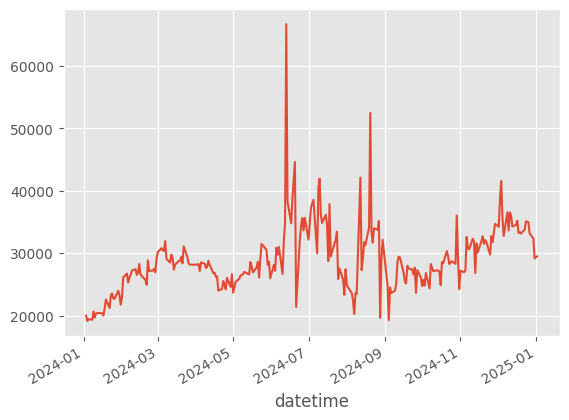

In [91]:

pm._equity['Total'].plot()

# Test New Config Management System

Testing the new config export/import functionality with path verification and validation.

In [117]:
## Test 1: Export configs with metadata
from EventDriven.configs.export_configs import export_run_configs

bundle = export_run_configs(evb_backtest, debug=False)

print(f"✓ Exported {len(bundle.configs)} configs")
print(f"✓ Run name: {bundle.run_name}")
print(f"✓ Created at: {bundle.created_at}")
print(f"\nConfigs exported:")
for label in list(bundle.configs.keys())[:5]:
    meta = bundle.metadata[label]
    print(f"  {label} -> {meta['path']}")

✓ Exported 15 configs
✓ Run name: 
✓ Created at: 2025-11-28 23:39:26.464696

Configs exported:
  BacktesterConfig_1 -> root.config
  RiskManagerConfig_1 -> root.risk_manager.config
  ChainConfig_1 -> root.risk_manager.order_picker._chain_config
  OrderPickerConfig_1 -> root.risk_manager.order_picker._order_picker_config
  OrderSchemaConfigs_1 -> root.risk_manager.order_picker._order_schema_config


**Note:** The config export now sanitizes all objects to YAML-safe basic types (str, int, float, bool, list, dict). Complex objects like nested configs, enums, and datetime objects are properly converted for safe serialization and deserialization.

In [118]:
## Test 2: Save to YAML (with proper sanitization)
import tempfile
import os

# Re-export to ensure we use the fixed version
from EventDriven.configs.export_configs import export_run_configs
bundle = export_run_configs(evb_backtest, debug=False)

# Save to temporary file
temp_path = os.path.join(tempfile.gettempdir(), 'test_config.yaml')
bundle.save_to_yaml(temp_path)

print(f"✓ Saved to: {temp_path}")
print(f"✓ File size: {os.path.getsize(temp_path)} bytes")

# Show first few lines of YAML
with open(temp_path, 'r') as f:
    lines = f.readlines()[:20]
    print("\nFirst 20 lines of YAML:")
    print("".join(lines))

✓ Saved to: /var/folders/j0/80hkbygd4lb27h9mw76gqzpw0000gn/T/test_config.yaml
✓ File size: 5468 bytes

First 20 lines of YAML:
run_name: ''
created_at: '2025-11-28T23:39:31.122141'
configs:
  BacktesterConfig_1:
    run_name: ''
    t_plus_n: 1
    finalize_trades: false
    raise_errors: false
    min_slippage_pct: 0.075
    max_slippage_pct: 0.15
  RiskManagerConfig_1:
    run_name: ''
    min_slippage_pct: 0.25
    max_slippage_pct: 0.16
    cache_orders: false
    cache_position_analysis: false
    cache_order_requests: false
  ChainConfig_1:
    run_name: ''
    max_pct_width: null



In [145]:
## Test 3: Load from YAML and validate
from EventDriven.configs.export_configs import RunConfigBundle

# Load the bundle
loaded_bundle = RunConfigBundle.load_from_yaml(temp_path)

print(f"✓ Loaded {len(loaded_bundle.configs)} configs")
print(f"✓ Run name: {loaded_bundle.run_name}")
print(f"✓ Has metadata: {len(loaded_bundle.metadata)} entries")
print(f"\nSample metadata:")
sample_label = list(loaded_bundle.metadata.keys())[0]
print(f"  {sample_label}:")
for key, val in loaded_bundle.metadata[sample_label].items():
    print(f"    {key}: {val}")

✓ Loaded 15 configs
✓ Run name: 
✓ Has metadata: 15 entries

Sample metadata:
  BacktesterConfig_1:
    config_class: BacktesterConfig
    path: root.config
    parent_path: root
    attribute_name: config


In [148]:
# Check what the NEW backtest's ChainConfig looks like
print("New backtest ChainConfig:")
print(dict(new_backtest.risk_manager.order_picker._chain_config.__dict__))

New backtest ChainConfig:
{'run_name': '', 'max_pct_width': None, 'min_oi': None}


In [147]:
## Test 4: Apply configs to new backtest with validation
# Create a new backtest instance
new_backtest = OptionSignalBacktest(trades_, initial_capital=cash)

# Apply the loaded configs with full validation
try:
    results = loaded_bundle.apply_to(new_backtest, strict=True, verify_paths=True)
    print(f"✓ Applied {len(results)} configs successfully!")
    print(f"\nSample applied configs:")
    for label, path in list(results.items())[:5]:
        print(f"  {label} -> {path}")
except Exception as e:
    print(f"✗ Error: {e}")

✗ Error: Failed to create/apply new config for ChainConfig_1: 2 validation errors for ChainConfig
max_pct_width
  Input should be an instance of Number [type=is_instance_of, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.11/v/is_instance_of
min_oi
  Input should be an instance of Number [type=is_instance_of, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.11/v/is_instance_of


In [121]:
## Test 5: Validate config placement
from EventDriven.configs.export_configs import validate_config_placement

# Validate the original backtest
errors = validate_config_placement(evb_backtest, raise_on_error=False)

if errors:
    print(f"✗ Found {len(errors)} validation errors:")
    for err in errors[:5]:  # Show first 5
        print(f"  - {err}")
else:
    print("✓ All configs are correctly placed!")

# Validate the new backtest
errors_new = validate_config_placement(new_backtest, raise_on_error=False)
if errors_new:
    print(f"\n✗ New backtest has {len(errors_new)} validation errors")
else:
    print("\n✓ New backtest configs are correctly placed!")

✗ Found 3 validation errors:
  - root.risk_manager.order_picker: Missing required config attribute 'config'
  - root.risk_manager.order_picker: Missing required config attribute 'order_schema_configs'
  - root.risk_manager.order_picker: Missing required config attribute 'chain_config'

✗ New backtest has 3 validation errors


In [116]:
## Test 6: Verify configs were applied correctly
# Check a few specific config values
print("Comparing config values between original and new backtest:\n")

# Check OrderSchemaConfigs
orig_schema = evb_backtest.risk_manager.order_picker.order_schema_configs
new_schema = new_backtest.risk_manager.order_picker.order_schema_configs

print(f"OrderSchemaConfigs.target_dte:")
print(f"  Original: {orig_schema.target_dte}")
print(f"  New: {new_schema.target_dte}")
print(f"  Match: {'✓' if orig_schema.target_dte == new_schema.target_dte else '✗'}")

print(f"\nBacktesterConfig.raise_errors:")
print(f"  Original: {evb_backtest.config.raise_errors}")
print(f"  New: {new_backtest.config.raise_errors}")
print(f"  Match: {'✓' if evb_backtest.config.raise_errors == new_backtest.config.raise_errors else '✗'}")

print(f"\nRiskManagerConfig.cache_orders:")
print(f"  Original: {evb_backtest.risk_manager.config.cache_orders}")
print(f"  New: {new_backtest.risk_manager.config.cache_orders}")
print(f"  Match: {'✓' if evb_backtest.risk_manager.config.cache_orders == new_backtest.risk_manager.config.cache_orders else '✗'}")

Comparing config values between original and new backtest:



AttributeError: 'OrderPicker' object has no attribute 'order_schema_configs'

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("/Users/chiemelienwanisobi/cloned_repos/configs")
# from configs.long_bbands._setup import setup_configs
from prod_strategies.long_bbands._setup import setup_backtest


Console Logging & File Logging Can be configured using STREAM_LOG_LEVEL and FILE_LOG_LEVEL in environment variables.
Propagate to root logger can be set using PROPAGATE_TO_ROOT_LOGGER in environment variables.
Example:
STREAM_LOG_LEVEL = 'DEBUG'
FILE_LOG_LEVEL = 'INFO'
PROPAGATE_TO_ROOT_LOGGER = 'False'

2025-11-29 00:44:17 trade.helpers.Logging INFO: Logging Root Directory: /Users/chiemelienwanisobi/cloned_repos/QuantTools/logs
Using Proxy URL: http://54.205.248.219:5500/thetadata
Using Proxy URL: http://54.205.248.219:5500/thetadata


Scheduled Data Requests will be saved to: /Users/chiemelienwanisobi/cloned_repos/QuantTools/module_test/raw_code/DataManagers/scheduler/requests.jsonl
2025-11-29 00:44:38 DataManager.py CRITICAL: Using ProcessSaveManager for saving data.


Scheduled Data Requests will be saved to: /Users/chiemelienwanisobi/cloned_repos/QuantTools/module_test/raw_code/DataManagers/scheduler/requests.jsonl
2025-11-29 00:44:38 DataManager.py CRITICAL: Using ProcessSaveMan

Loading BokehJS ...

In [6]:
bkt = setup_backtest(
    trades=trades_, initial_capital=cash
)
bkt

[get_engine] Creating engine for DB: securities_master, PID: 68293


In [9]:
bkt.portfolio.config

PortfolioManagerConfig(run_name='bkt_test_11', weights_haircut=0.05, roll_failed_orders=False)